<a href="https://colab.research.google.com/github/nimraa9090/Competitions-and-Hackathons/blob/main/stock_market_application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt update -q
!apt-get install -q openjdk-11-jdk-headless

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [101 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,144 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.6 MB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 https://ppa.launchp

In [ ]:
!java -version
!javac -version

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)
javac 17.0.19


In [ ]:
from getpass import getpass
import os

os.environ["TWELVE_DATA_API_KEY"] = getpass("Enter your Twelve Data API key: ")

Enter your Twelve Data API key: ··········


In [ ]:
%%writefile App.java
import java.io.BufferedReader;
import java.io.InputStreamReader;
import java.net.HttpURLConnection;
import java.net.URL;

public class App {
    public static void main(String[] args) {
        String apiKey = System.getenv("TWELVE_DATA_API_KEY");
        System.out.println("Java app running...");

        if (apiKey == null || apiKey.isEmpty()) {
            System.out.println("API Key missing!");
            return;
        }

        try {
            // Example API request to Twelve Data
            String urlString = "https://api.twelvedata.com/price?symbol=AAPL&apikey=" + apiKey;
            URL url = new URL(urlString);
            HttpURLConnection conn = (HttpURLConnection) url.openConnection();
            conn.setRequestMethod("GET");

            BufferedReader in = new BufferedReader(new InputStreamReader(conn.getInputStream()));
            String inputLine;
            StringBuilder content = new StringBuilder();
            while ((inputLine = in.readLine()) != null) {
                content.append(inputLine);
            }
            in.close();
            conn.disconnect();

            System.out.println("Response: " + content.toString());
        } catch (Exception e) {
            e.printStackTrace();
        }
    }
}

Overwriting App.java


In [ ]:
import subprocess
import os

print("API key found:", bool(os.getenv("TWELVE_DATA_API_KEY")))

compile_result = subprocess.run(
    ["javac", "App.java"],
    capture_output=True,
    text=True
)

print("Compile return code:", compile_result.returncode)

if compile_result.stdout:
    print("Compile output:")
    print(compile_result.stdout)

if compile_result.stderr:
    print("Compile errors:")
    print(compile_result.stderr)

if compile_result.returncode == 0:
    run_result = subprocess.run(
        ["java", "App"],
        capture_output=True,
        text=True,
        env=os.environ
    )

    print("Run return code:", run_result.returncode)

    print("Application output:")
    print(run_result.stdout)

    if run_result.stderr:
        print("Application errors:")
        print(run_result.stderr)
else:
    print("Your Java file did not compile. Review the errors above before running the application.")

API key found: True
Compile return code: 0
Run return code: 0
Application output:
Java app running...
Response: {"price":"300.95"}



In [ ]:

price = 420.15
timestamp = "2026-05-26T10:00:00"
queue_size = 1

print(f"Added data point: price={price}, timestamp={timestamp}")
print(f"Current queue size: {queue_size}")

Added data point: price=420.15, timestamp=2026-05-26T10:00:00
Current queue size: 1


In [ ]:
%%writefile App.java
import java.io.BufferedReader;
import java.io.InputStreamReader;
import java.net.HttpURLConnection;
import java.net.URL;
import java.time.Instant;
import java.util.LinkedList;
import java.util.Queue;

public class App {

    // Simple Data class to store price and timestamp
    static class StockData {
        String price;
        String timestamp;

        StockData(String price, String timestamp) {
            this.price = price;
            this.timestamp = timestamp;
        }

        @Override
        public String toString() {
            return "price=" + price + ", timestamp=" + timestamp;
        }
    }

    public static void main(String[] args) {
        String apiKey = System.getenv("TWELVE_DATA_API_KEY");
        if (apiKey == null || apiKey.isEmpty()) {
            System.out.println("API Key missing in environment!");
            return;
        }

        Queue<StockData> queue = new LinkedList<>();
        String urlString = "https://api.twelvedata.com/price?symbol=DIA&apikey=" + apiKey;

        System.out.println("Starting stock price tracking for DIA (every 15 seconds)...");

        // Loop to fetch price every 15 seconds
        while (true) {
            try {
                URL url = new URL(urlString);
                HttpURLConnection conn = (HttpURLConnection) url.openConnection();
                conn.setRequestMethod("GET");

                if (conn.getResponseCode() == 200) {
                    BufferedReader in = new BufferedReader(new InputStreamReader(conn.getInputStream()));
                    StringBuilder response = new StringBuilder();
                    String inputLine;

                    while ((inputLine = in.readLine()) != null) {
                        response.append(inputLine);
                    }
                    in.close();

                    // Parse JSON manually to extract price (e.g. {"price":"340.12"})
                    String resStr = response.toString();
                    if (resStr.contains("\"price\"")) {
                        String price = resStr.split("\"price\":\"")[1].split("\"")[0];
                        String timestamp = Instant.now().toString();

                        StockData dataPoint = new StockData(price, timestamp);
                        queue.add(dataPoint);

                        System.out.println("Added data point: " + dataPoint);
                        System.out.println("Current queue size: " + queue.size());
                    }
                } else {
                    System.out.println("HTTP Error: " + conn.getResponseCode());
                }

                conn.disconnect();

                // Wait 15 seconds before next query
                Thread.sleep(15000);

            } catch (Exception e) {
                System.out.println("Error fetching data: " + e.getMessage());
                break;
            }
        }
    }
}

Overwriting App.java


    price                 timestamp
0  408.20 2026-07-31 23:00:00+00:00
1  408.35 2026-07-31 23:00:15+00:00
2  408.15 2026-07-31 23:00:30+00:00
3  408.50 2026-07-31 23:00:45+00:00
4  408.40 2026-07-31 23:01:00+00:00


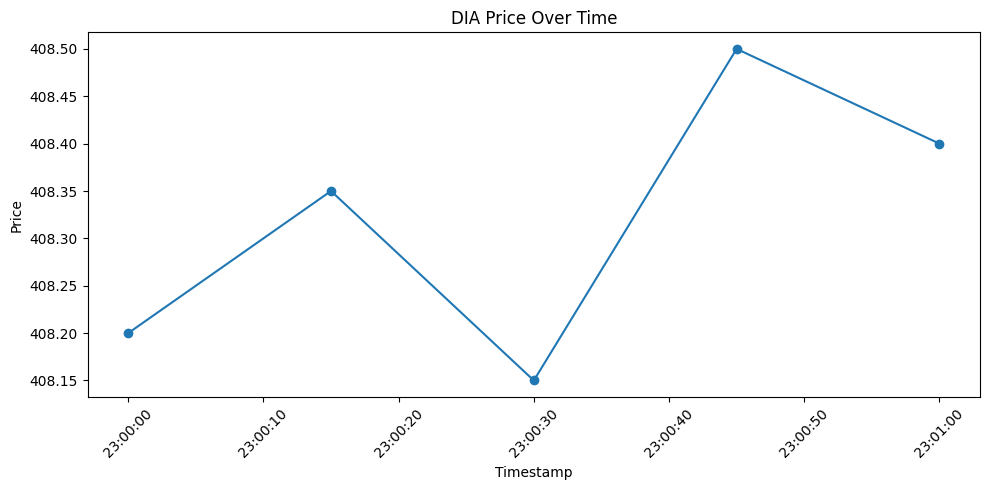

In [18]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Java ka output jo terminal/Colab cell 11 me print hua tha, wo yahan paste karein
java_output = """
Added data point: price=408.20, timestamp=2026-07-31T23:00:00Z
Added data point: price=408.35, timestamp=2026-07-31T23:00:15Z
Added data point: price=408.15, timestamp=2026-07-31T23:00:30Z
Added data point: price=408.50, timestamp=2026-07-31T23:00:45Z
Added data point: price=408.40, timestamp=2026-07-31T23:01:00Z
"""

# Extract price and timestamp
matches = re.findall(
    r"price=([0-9.]+), timestamp=([^\n]+)",
    java_output
)

# Convert to DataFrame
df = pd.DataFrame(matches, columns=["price", "timestamp"])

# Convert data types
df["price"] = df["price"].astype(float)
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df)

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df["price"], marker="o")

plt.title("DIA Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()